<a href="https://colab.research.google.com/github/nehalnady/DM_Project/blob/main/DM_Classification_Task_Updated.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, roc_auc_score,
                              roc_curve, classification_report)
from sklearn.feature_selection import SelectFromModel
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

print("All libraries imported successfully.")

All libraries imported successfully.


In [2]:
# ============================================================
# STEP 0: Load Dataset
# ============================================================
df = pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn.csv')

print("=" * 60)
print("STEP 0: Dataset Loaded")
print("=" * 60)
print(f"  Shape       : {df.shape}")
print(f"  Columns     : {list(df.columns)}")
print(f"\n  Data Types:")
print(df.dtypes.to_string())
print(f"\n  First 5 rows:")
df.head()

STEP 0: Dataset Loaded
  Shape       : (7043, 21)
  Columns     : ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

  Data Types:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object

  Firs

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# ============================================================
# STEP 1: Remove Non-Informative Column (customerID)
# ============================================================
df.drop(columns=["customerID"], inplace=True)

print("=" * 60)
print("STEP 1: customerID Column Removed")
print("=" * 60)
print(f"  Shape after drop: {df.shape}")

STEP 1: customerID Column Removed
  Shape after drop: (7043, 20)


In [4]:
# ============================================================
# STEP 2: Remove Duplicates
# ============================================================
before = len(df)
df.drop_duplicates(inplace=True)
after  = len(df)

print("=" * 60)
print("STEP 2: Duplicate Removal")
print("=" * 60)
print(f"  Rows before         : {before}")
print(f"  Rows after          : {after}")
print(f"  Duplicates removed  : {before - after}")

STEP 2: Duplicate Removal
  Rows before         : 7043
  Rows after          : 7021
  Duplicates removed  : 22


In [5]:
# ============================================================
# STEP 3: Fix Data Types & Identify Missing Values
# ============================================================

# TotalCharges contains spaces -> convert to numeric (spaces become NaN)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

print("=" * 60)
print("STEP 3: Data Types Fixed — Missing Values Report")
print("=" * 60)
missing = df.isnull().sum()
print("  Missing values per column:")
print(missing.to_string())
print(f"\n  Total missing cells : {missing.sum()}")
print("  (TotalCharges spaces converted to NaN — will be imputed next)")

STEP 3: Data Types Fixed — Missing Values Report
  Missing values per column:
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0

  Total missing cells : 11
  (TotalCharges spaces converted to NaN — will be imputed next)


In [6]:
# ============================================================
# STEP 4: Handle Missing Values with SimpleImputer
# ============================================================

numeric_cols     = df.select_dtypes(include=["float64","int64"]).columns.tolist()
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()

print("=" * 60)
print("STEP 4: SimpleImputer — Missing Value Treatment")
print("=" * 60)
print(f"  Numeric    columns: {numeric_cols}")
print(f"  Categorical columns: {categorical_cols}")

# Numeric  → median imputation
num_imputer = SimpleImputer(strategy="median")
df[numeric_cols] = num_imputer.fit_transform(df[numeric_cols])

# Categorical → most_frequent imputation
cat_imputer = SimpleImputer(strategy="most_frequent")
df[categorical_cols] = cat_imputer.fit_transform(df[categorical_cols])

print("\n  Strategy applied:")
print("    Numeric    cols → strategy = 'median'")
print("    Categorical cols → strategy = 'most_frequent'")
print("\n  Missing values AFTER imputation:")
print(df.isnull().sum().to_string())
print("\n  All missing values handled!")

STEP 4: SimpleImputer — Missing Value Treatment
  Numeric    columns: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
  Categorical columns: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']

  Strategy applied:
    Numeric    cols → strategy = 'median'
    Categorical cols → strategy = 'most_frequent'

  Missing values AFTER imputation:
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0

  All 

In [7]:
# ============================================================
# STEP 5: Encoding — Label Encoder + One-Hot Encoder
# ============================================================

print("=" * 60)
print("STEP 5: Encoding")
print("=" * 60)

# ── Binary columns → Label Encoder ──────────────────────────
binary_cols = ["gender", "Partner", "Dependents",
               "PhoneService", "PaperlessBilling", "Churn"]

le = LabelEncoder()
for col in binary_cols:
    original_vals = df[col].unique()
    df[col] = le.fit_transform(df[col])
    print(f"  LabelEncoder  | {col:20s}: {list(original_vals)} → {sorted(df[col].unique().tolist())}")

print()

# ── Multi-class columns → One-Hot Encoder ───────────────────
multi_cols = ["MultipleLines", "InternetService", "OnlineSecurity",
              "OnlineBackup", "DeviceProtection", "TechSupport",
              "StreamingTV", "StreamingMovies", "Contract", "PaymentMethod"]

shape_before = df.shape
df = pd.get_dummies(df, columns=multi_cols, drop_first=True)
shape_after  = df.shape

for col in multi_cols:
    print(f"  OneHotEncoder | {col:20s}: encoded as dummies (drop_first=True)")

print(f"\n  Shape before OHE : {shape_before}")
print(f"  Shape after  OHE : {shape_after}")
print(f"\n  Columns after encoding:")
print(list(df.columns))

STEP 5: Encoding
  LabelEncoder  | gender              : ['Female', 'Male'] → [0, 1]
  LabelEncoder  | Partner             : ['Yes', 'No'] → [0, 1]
  LabelEncoder  | Dependents          : ['No', 'Yes'] → [0, 1]
  LabelEncoder  | PhoneService        : ['No', 'Yes'] → [0, 1]
  LabelEncoder  | PaperlessBilling    : ['Yes', 'No'] → [0, 1]
  LabelEncoder  | Churn               : ['No', 'Yes'] → [0, 1]

  OneHotEncoder | MultipleLines       : encoded as dummies (drop_first=True)
  OneHotEncoder | InternetService     : encoded as dummies (drop_first=True)
  OneHotEncoder | OnlineSecurity      : encoded as dummies (drop_first=True)
  OneHotEncoder | OnlineBackup        : encoded as dummies (drop_first=True)
  OneHotEncoder | DeviceProtection    : encoded as dummies (drop_first=True)
  OneHotEncoder | TechSupport         : encoded as dummies (drop_first=True)
  OneHotEncoder | StreamingTV         : encoded as dummies (drop_first=True)
  OneHotEncoder | StreamingMovies     : encoded as dummies (

In [8]:
# ============================================================
# STEP 6: Outlier Detection & Handling (IQR Method)
# ============================================================

print("=" * 60)
print("STEP 6: Outlier Detection — IQR Method")
print("=" * 60)

outlier_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

for col in outlier_cols:
    Q1      = df[col].quantile(0.25)
    Q3      = df[col].quantile(0.75)
    IQR     = Q3 - Q1
    lower   = Q1 - 1.5 * IQR
    upper   = Q3 + 1.5 * IQR
    n_out   = ((df[col] < lower) | (df[col] > upper)).sum()
    print(f"  {col:20s} | Q1={Q1:.2f}  Q3={Q3:.2f}  IQR={IQR:.2f}")
    print(f"  {'':20s} | Lower={lower:.2f}  Upper={upper:.2f}  Outliers found={n_out}")
    df[col] = df[col].clip(lower, upper)
    print(f"  {'':20s} | Clipped to valid range.\n")

print("  Outlier handling complete.")

STEP 6: Outlier Detection — IQR Method
  tenure               | Q1=9.00  Q3=55.00  IQR=46.00
                       | Lower=-60.00  Upper=124.00  Outliers found=0
                       | Clipped to valid range.

  MonthlyCharges       | Q1=35.75  Q3=89.90  IQR=54.15
                       | Lower=-45.48  Upper=171.12  Outliers found=0
                       | Clipped to valid range.

  TotalCharges         | Q1=411.15  Q3=3801.70  IQR=3390.55
                       | Lower=-4674.68  Upper=8887.52  Outliers found=0
                       | Clipped to valid range.

  Outlier handling complete.


In [9]:
# ============================================================
# STEP 7: Feature Scaling
#          MinMaxScaler  → Normalization  (MonthlyCharges, TotalCharges)
#          StandardScaler → Standardization (tenure)
# ============================================================

print("=" * 60)
print("STEP 7: Feature Scaling — Normalization + Standardization")
print("=" * 60)

X = df.drop("Churn", axis=1)
y = df["Churn"]

normalize_cols    = ["MonthlyCharges", "TotalCharges"]   # → [0, 1]
standardize_cols  = ["tenure"]                            # → mean=0, std=1

print("  Before scaling:")
print(f"  MonthlyCharges  range : [{X['MonthlyCharges'].min():.2f}, {X['MonthlyCharges'].max():.2f}]")
print(f"  TotalCharges    range : [{X['TotalCharges'].min():.2f},  {X['TotalCharges'].max():.2f}]")
print(f"  tenure          range : [{X['tenure'].min():.2f},  {X['tenure'].max():.2f}]")

# Normalization (MinMax)
min_max_scaler = MinMaxScaler()
X[normalize_cols] = min_max_scaler.fit_transform(X[normalize_cols])

# Standardization (Standard)
std_scaler = StandardScaler()
X[standardize_cols] = std_scaler.fit_transform(X[standardize_cols])

print("\n  After scaling:")
print(f"  MonthlyCharges  range : [{X['MonthlyCharges'].min():.4f}, {X['MonthlyCharges'].max():.4f}]  ← MinMaxScaler (Normalized)")
print(f"  TotalCharges    range : [{X['TotalCharges'].min():.4f},  {X['TotalCharges'].max():.4f}]  ← MinMaxScaler (Normalized)")
print(f"  tenure          mean  : {X['tenure'].mean():.4f}  std: {X['tenure'].std():.4f}          ← StandardScaler (Standardized)")
print("\n  Sample of scaled features (first 5 rows):")
print(X[normalize_cols + standardize_cols].head().to_string())

STEP 7: Feature Scaling — Normalization + Standardization
  Before scaling:
  MonthlyCharges  range : [18.25, 118.75]
  TotalCharges    range : [18.80,  8684.80]
  tenure          range : [0.00,  72.00]

  After scaling:
  MonthlyCharges  range : [0.0000, 1.0000]  ← MinMaxScaler (Normalized)
  TotalCharges    range : [0.0000,  1.0000]  ← MinMaxScaler (Normalized)
  tenure          mean  : 0.0000  std: 1.0001          ← StandardScaler (Standardized)

  Sample of scaled features (first 5 rows):
   MonthlyCharges  TotalCharges    tenure
0        0.115423      0.001275 -1.282728
1        0.385075      0.215867  0.062387
2        0.354229      0.010310 -1.241967
3        0.239303      0.210241  0.510759
4        0.521891      0.015330 -1.241967


In [10]:
# ============================================================
# STEP 8: Feature Selection (RandomForest + SelectFromModel)
# ============================================================

print("=" * 60)
print("STEP 8: Feature Selection")
print("=" * 60)

rf_fs = RandomForestClassifier(n_estimators=100, random_state=42)
rf_fs.fit(X, y)

selector         = SelectFromModel(rf_fs, prefit=True, threshold="mean")
X_selected       = selector.transform(X)
selected_features = X.columns[selector.get_support()]

print(f"  Total features before selection : {X.shape[1]}")
print(f"  Features selected               : {X_selected.shape[1]}")
print(f"  Selected feature names          : {list(selected_features)}")

STEP 8: Feature Selection
  Total features before selection : 30
  Features selected               : 5
  Selected feature names          : ['tenure', 'MonthlyCharges', 'TotalCharges', 'InternetService_Fiber optic', 'PaymentMethod_Electronic check']


In [11]:
# ============================================================
# STEP 9: Handle Class Imbalance
# ============================================================

print("=" * 60)
print("STEP 9: Class Imbalance Analysis & SMOTE")
print("=" * 60)

X_sel_df      = pd.DataFrame(X_selected, columns=selected_features)
class_counts  = pd.Series(y).value_counts().sort_index()
total         = len(y)

print(f"  Class distribution BEFORE balancing:")
print(f"    Class 0 (Stay)  : {class_counts[0]}  ({100*class_counts[0]/total:.1f}%)")
print(f"    Class 1 (Churn) : {class_counts[1]}  ({100*class_counts[1]/total:.1f}%)")
print(f"  Imbalance ratio   : {class_counts.max() / class_counts.min():.2f} : 1")

# Apply SMOTE (over-sampling minority class)
print("\n  → Imbalance detected (ratio > 1.5)")
print("  → Applying SMOTE (Synthetic Minority Over-sampling Technique)")

sm           = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X_sel_df, y)

balanced_counts = pd.Series(y_res).value_counts().sort_index()
print(f"\n  Class distribution AFTER SMOTE:")
print(f"    Class 0 (Stay)  : {balanced_counts[0]}")
print(f"    Class 1 (Churn) : {balanced_counts[1]}")
print(f"  New imbalance ratio: {balanced_counts.max() / balanced_counts.min():.2f} : 1  (balanced!)")

STEP 9: Class Imbalance Analysis & SMOTE
  Class distribution BEFORE balancing:
    Class 0 (Stay)  : 5164  (73.6%)
    Class 1 (Churn) : 1857  (26.4%)
  Imbalance ratio   : 2.78 : 1

  → Imbalance detected (ratio > 1.5)
  → Applying SMOTE (Synthetic Minority Over-sampling Technique)

  Class distribution AFTER SMOTE:
    Class 0 (Stay)  : 5164
    Class 1 (Churn) : 5164
  New imbalance ratio: 1.00 : 1  (balanced!)


In [12]:
# ============================================================
# STEP 10: Train / Test Split (80/20)
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X_res, y_res, test_size=0.20, random_state=42, stratify=y_res
)

print("=" * 60)
print("STEP 10: Train/Test Split (80/20)")
print("=" * 60)
print(f"  Total samples after SMOTE : {len(X_res)}")
print(f"  Training samples          : {X_train.shape[0]}  (80%)")
print(f"  Testing  samples          : {X_test.shape[0]}   (20%)")
print(f"  Number of features        : {X_train.shape[1]}")

STEP 10: Train/Test Split (80/20)
  Total samples after SMOTE : 10328
  Training samples          : 8262  (80%)
  Testing  samples          : 2066   (20%)
  Number of features        : 5


In [13]:
# ============================================================
# STEP 11: Model Training + 5-Fold Cross-Validation
# ============================================================

print("=" * 60)
print("STEP 11: Model Training — GradientBoostingClassifier")
print("=" * 60)

model = GradientBoostingClassifier(
    n_estimators=200, learning_rate=0.1, max_depth=4, random_state=42
)
cv          = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores   = cross_val_score(model, X_train, y_train, cv=cv, scoring="f1")

print(f"  Cross-val F1 (5-fold) : {cv_scores.round(4)}")
print(f"  Mean CV F1            : {cv_scores.mean():.4f}")
print(f"  Std  CV F1            : {cv_scores.std():.4f}")

model.fit(X_train, y_train)
print("\n  Model fitted on training data.")

STEP 11: Model Training — GradientBoostingClassifier
  Cross-val F1 (5-fold) : [0.7889 0.7952 0.8065 0.7822 0.8061]
  Mean CV F1            : 0.7958
  Std  CV F1            : 0.0095

  Model fitted on training data.


In [14]:
# ============================================================
# STEP 12: Predict New Values
# ============================================================

print("=" * 60)
print("STEP 12: Predictions on New Samples (first 5 test rows)")
print("=" * 60)

new_samples = X_test[:5]
new_preds   = model.predict(new_samples)
new_proba   = model.predict_proba(new_samples)[:, 1]

print(f"  {'Customer':<12} {'Prediction':<12} {'Churn Probability'}")
print("  " + "-" * 40)
for i, (pred, prob) in enumerate(zip(new_preds, new_proba)):
    label = "CHURN" if pred == 1 else "STAY"
    print(f"  Customer {i+1:<3}  {label:<12} {prob:.2%}")

STEP 12: Predictions on New Samples (first 5 test rows)
  Customer     Prediction   Churn Probability
  ----------------------------------------
  Customer 1    STAY         1.59%
  Customer 2    CHURN        65.51%
  Customer 3    STAY         32.73%
  Customer 4    STAY         27.35%
  Customer 5    STAY         35.14%


In [15]:
# ============================================================
# STEP 13: Evaluation Metrics
# ============================================================

print("=" * 60)
print("STEP 13: Evaluation Metrics")
print("=" * 60)

y_pred  = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)
auc  = roc_auc_score(y_test, y_proba)

print(f"  Accuracy  : {acc:.4f}")
print(f"  Precision : {prec:.4f}")
print(f"  Recall    : {rec:.4f}")
print(f"  F1-Score  : {f1:.4f}")
print(f"  ROC-AUC   : {auc:.4f}")
print(f"\n  Full Classification Report:")
print(classification_report(y_test, y_pred, target_names=["Stay","Churn"]))

STEP 13: Evaluation Metrics
  Accuracy  : 0.7744
  Precision : 0.7529
  Recall    : 0.8170
  F1-Score  : 0.7837
  ROC-AUC   : 0.8551

  Full Classification Report:
              precision    recall  f1-score   support

        Stay       0.80      0.73      0.76      1033
       Churn       0.75      0.82      0.78      1033

    accuracy                           0.77      2066
   macro avg       0.78      0.77      0.77      2066
weighted avg       0.78      0.77      0.77      2066



Mounted at /content/drive


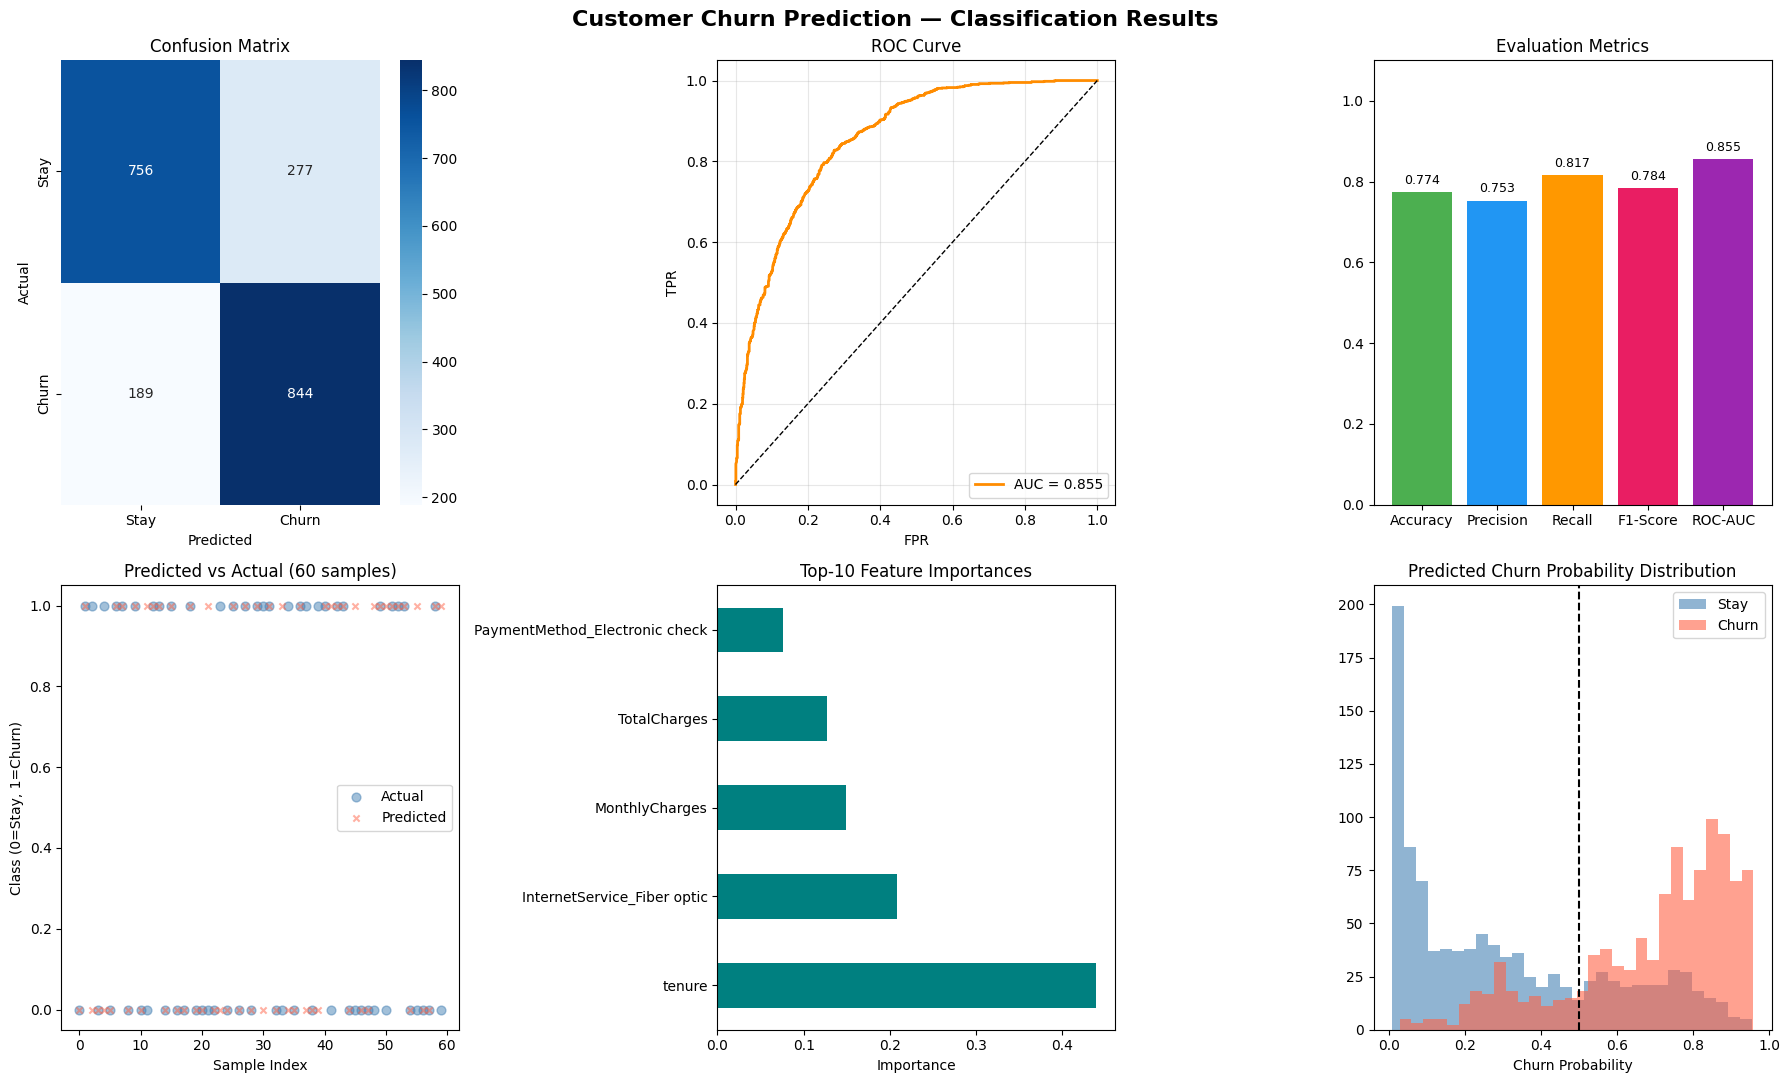

Saved to Google Drive.


In [16]:
# ============================================================
# STEP 14: Visualizations
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle(
    "Customer Churn Prediction — Classification Results",
    fontsize=16, fontweight="bold"
)

# 1. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0, 0],
            xticklabels=["Stay", "Churn"], yticklabels=["Stay", "Churn"])
axes[0, 0].set_title("Confusion Matrix")
axes[0, 0].set_ylabel("Actual")
axes[0, 0].set_xlabel("Predicted")

# 2. ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[0, 1].plot(fpr, tpr, color="darkorange", lw=2, label=f"AUC = {auc:.3f}")
axes[0, 1].plot([0, 1], [0, 1], "k--", lw=1)
axes[0, 1].set_title("ROC Curve")
axes[0, 1].set_xlabel("FPR")
axes[0, 1].set_ylabel("TPR")
axes[0, 1].legend(loc="lower right")
axes[0, 1].grid(True, alpha=0.3)

# 3. Evaluation Metrics Bar Chart
metrics = {"Accuracy": acc, "Precision": prec, "Recall": rec,
           "F1-Score": f1,  "ROC-AUC": auc}
axes[0, 2].bar(metrics.keys(), metrics.values(),
               color=["#4CAF50","#2196F3","#FF9800","#E91E63","#9C27B0"])
axes[0, 2].set_ylim(0, 1.1)
axes[0, 2].set_title("Evaluation Metrics")
for i, v in enumerate(metrics.values()):
    axes[0, 2].text(i, v + 0.02, f"{v:.3f}", ha="center", fontsize=9)

# 4. Predicted vs Actual (first 60 test samples)
n_show = 60
y_test_arr = np.array(y_test)
axes[1, 0].scatter(range(n_show), y_test_arr[:n_show],
                   alpha=0.5, label="Actual",    color="steelblue", s=40)
axes[1, 0].scatter(range(n_show), y_pred[:n_show],
                   alpha=0.5, label="Predicted", color="tomato",    s=20, marker="x")
axes[1, 0].set_title("Predicted vs Actual (60 samples)")
axes[1, 0].set_xlabel("Sample Index")
axes[1, 0].set_ylabel("Class (0=Stay, 1=Churn)")
axes[1, 0].legend()

# 5. Feature Importances
importances = model.feature_importances_
feat_imp    = pd.Series(importances, index=selected_features).nlargest(10)
feat_imp.plot(kind="barh", ax=axes[1, 1], color="teal")
axes[1, 1].set_title("Top-10 Feature Importances")
axes[1, 1].set_xlabel("Importance")

# 6. Churn Probability Distribution
axes[1, 2].hist(y_proba[y_test_arr == 0], bins=30, alpha=0.6,
                label="Stay",  color="steelblue")
axes[1, 2].hist(y_proba[y_test_arr == 1], bins=30, alpha=0.6,
                label="Churn", color="tomato")
axes[1, 2].axvline(0.5, color="black", linestyle="--", linewidth=1.5)
axes[1, 2].set_title("Predicted Churn Probability Distribution")
axes[1, 2].set_xlabel("Churn Probability")
axes[1, 2].legend()

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/task1_classification_churn_updated.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved to Google Drive.")